Initializing data fetch...

Processing VRTX (1y)


[*********************100%***********************]  1 of 1 completed


Processing LULU (9mo)


[*********************100%***********************]  1 of 1 completed


Processing ODFL (6mo)


[*********************100%***********************]  1 of 1 completed


Processing ENPH (3mo)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Processing DKNG (1mo)



KPI Report:
  Ticker Period  Latency (s)  Completeness (%)  Accuracy (%)  Consistent
0   VRTX     1y       0.2464             100.0         100.0        True
1   LULU    9mo       0.2451             100.0         100.0        True
2   ODFL    6mo       0.3397             100.0         100.0        True
3   ENPH    3mo       0.2512             100.0         100.0        True
4   DKNG    1mo       0.1954             100.0         100.0        True

Descriptive Statistics for VRTX (1 Year):

Price    Close    High     Low    Open       Volume
Ticker    VRTX    VRTX    VRTX    VRTX         VRTX
count   252.00  252.00  252.00  252.00       252.00
mean    440.21  445.56  434.96  440.10   1536626.19
std      30.31   30.63   29.76   30.22    971250.85
min     366.54  380.20  362.50  362.97    196700.00
25%     421.34  426.97  416.99  419.12   1056675.00
50%     444.10  448.30  439.29  444.08   1334550.00
75%     461.17  467.21  457.01  462.00   1697500.00
max     509.50  510.77  498.21  507.0

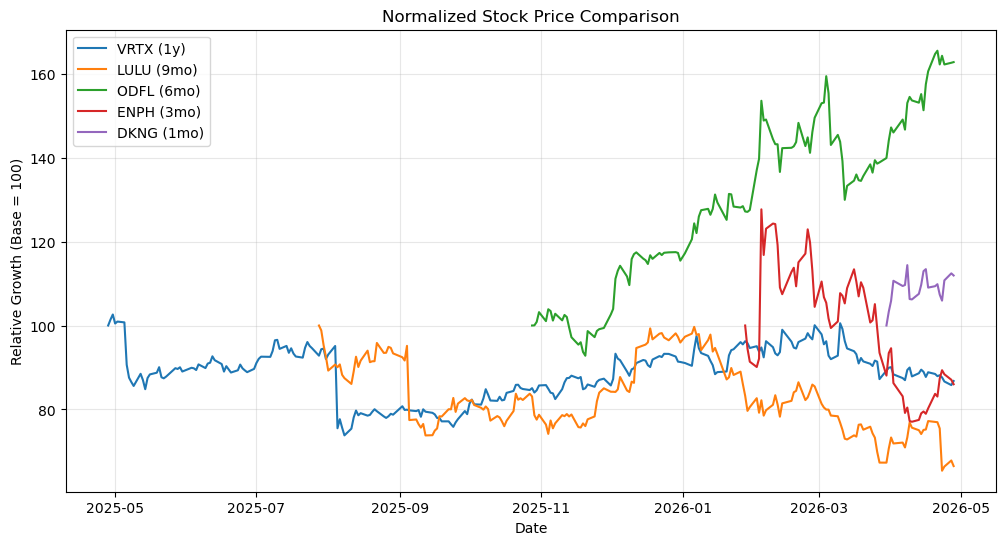


All files saved successfully.


In [4]:
# ==============================
# Imports and Setup
# ==============================
import os
import time
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Create folders
os.makedirs("data", exist_ok=True)
os.makedirs("plots", exist_ok=True)

# ==============================
# Configuration
# ==============================
configs = {
    'VRTX': '1y',
    'LULU': '9mo',
    'ODFL': '6mo',
    'ENPH': '3mo',
    'DKNG': '1mo'
}

kpi_results = []
all_data = {}

print("Initializing data fetch...\n")

# ==============================
# Data Collection and KPI Evaluation
# ==============================
for ticker, period in configs.items():
    print(f"Processing {ticker} ({period})")

    start_time = time.time()
    
    # Fetch raw data
    df_raw = yf.download(ticker, period=period)

    # KPI (a): Completeness (based on raw data)
    completeness = (1 - df_raw.isnull().sum().sum() / df_raw.size) * 100

    # KPI (b): Latency
    latency = time.time() - start_time

    # Clean data after KPI measurement
    df = df_raw.dropna()

    # KPI (c): Accuracy
    accuracy_issues = ((df['Close'] <= 0) | (df['Volume'] < 0)).sum().sum()
    accuracy_score = round((1 - accuracy_issues / len(df)) * 100, 2)

    # KPI (d): Consistency
    expected_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    consistency = all(col in df.columns for col in expected_cols)

    # Store results
    kpi_results.append({
        'Ticker': ticker,
        'Period': period,
        'Latency (s)': round(latency, 4),
        'Completeness (%)': round(completeness, 2),
        'Accuracy (%)': accuracy_score,
        'Consistent': consistency
    })

    all_data[ticker] = df

# ==============================
# KPI Report
# ==============================
kpi_df = pd.DataFrame(kpi_results)

print("\nKPI Report:")
print(kpi_df)

# Save KPI report
kpi_df.to_csv("kpi_report.csv", index=False)

# ==============================
# Descriptive Statistics
# ==============================
print("\nDescriptive Statistics for VRTX (1 Year):\n")
print(all_data['VRTX'].describe().round(2))

# ==============================
# Visualization
# ==============================
plt.figure(figsize=(12, 6))

for ticker, df in all_data.items():
    normalized_price = (df['Close'] / df['Close'].iloc[0]) * 100
    plt.plot(df.index, normalized_price, label=f"{ticker} ({configs[ticker]})")

plt.title("Normalized Stock Price Comparison")
plt.xlabel("Date")
plt.ylabel("Relative Growth (Base = 100)")
plt.legend()
plt.grid(alpha=0.3)

# Save plot before displaying
plt.savefig("plots/price_comparison.png")
plt.show()

# ==============================
# Save Individual Datasets
# ==============================
for ticker, df in all_data.items():
    df.to_csv(f"data/{ticker}.csv")

print("\nAll files saved successfully.")